# Rotation Sensitivity Analysis

This notebook analyses how [cp_measure](https://github.com/afermg/cp_measure)
morphological features vary as a function of image rotation — a key question
for understanding which CellProfiler-compatible features are truly
rotation-invariant and which are artefacts of image orientation.

## Dataset

`rotation_dataset.ome.parquet` contains **115,200 measurements**:

| Dimension | Values | Count |
|-----------|--------|-------|
| Cells | 80 parameter configs × 20 random seeds | 1,600 |
| Angles | 0°, 5°, 10°, …, 355° | 72 |
| **Total rows** | 1,600 × 72 | **115,200** |

**Parameter grid:**

| Parameter | Values |
|-----------|--------|
| Mask shape | `EllipseMask` |
| Aspect ratio (x/y) | 1.0, 1.5, 2.0, 3.0, 4.0 |
| Cell size (y_radius px) | 60, 100, 150, 200 |
| Stain | `SpatialStain(σ=5)`, `SpatialStain(σ=20)`, `SpatialStain(σ=60)`, `ConstantStain` |
| Seeds per config | 20 (controls stain noise) |

Each row stores the 128×128 intensity image and segmentation mask as
[OME-Arrow](https://github.com/wayscience/ome-arrow) structs alongside
~372 cp_measure feature columns.

**Prerequisites:** run `simulate_rotation_sweep.py` first to generate the dataset.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from cytodataframe import CytoDataFrame

DATASET = Path("rotation_dataset.ome.parquet")
assert DATASET.exists(), f"Run simulate_rotation_sweep.py first — {DATASET} not found"

META_COLS = [
    "cell_id",
    "angle_deg",
    "aspect_ratio",
    "y_radius",
    "stain_type",
    "stain_corr",
    "seed",
]
IMAGE_COLS = ["image", "mask"]

## 1 — Dataset at a glance

In [2]:
# Schema and size summary
schema = pq.read_schema(DATASET)
feature_cols = [f.name for f in schema if f.name not in META_COLS + IMAGE_COLS]

size_mb = DATASET.stat().st_size / 1e6

print(f"File:           {DATASET.name}")
print(f"Size:           {size_mb:.0f} MB (ZSTD-compressed Parquet)")
print("Total rows:     115,200  (1,600 cells × 72 angles)")
print(f"Total columns:  {len(schema)}")
print(f"  Metadata:     {len(META_COLS)}  ({', '.join(META_COLS)})")
print(f"  Image/mask:   {len(IMAGE_COLS)}  (OME-Arrow structs, 128×128 px)")
print(f"  Features:     {len(feature_cols)}  (cp_measure, float32)")

File:           rotation_dataset.ome.parquet
Size:           478 MB (ZSTD-compressed Parquet)
Total rows:     115,200  (1,600 cells × 72 angles)
Total columns:  381
  Metadata:     7  (cell_id, angle_deg, aspect_ratio, y_radius, stain_type, stain_corr, seed)
  Image/mask:   2  (OME-Arrow structs, 128×128 px)
  Features:     372  (cp_measure, float32)


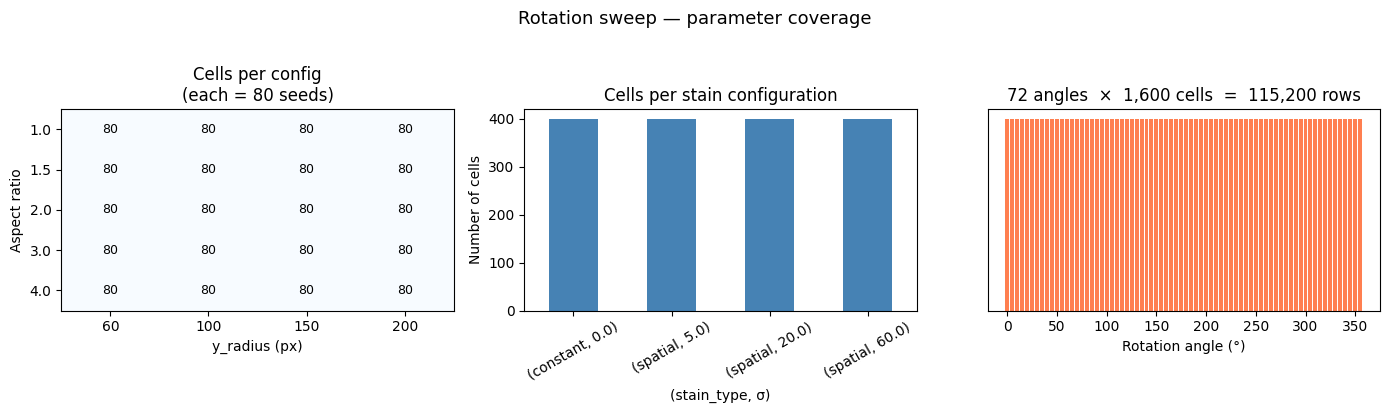

In [3]:
# Parameter grid coverage — how cells are distributed
meta = pq.read_table(DATASET, columns=META_COLS).to_pandas()
at_zero = meta[meta["angle_deg"] == 0].copy()  # one row per cell

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Aspect ratio × y_radius heatmap
pivot = at_zero.groupby(["aspect_ratio", "y_radius"]).size().unstack()
axes[0].imshow(pivot.values, aspect="auto", cmap="Blues")
axes[0].set_xticks(range(len(pivot.columns)))
axes[0].set_xticklabels(pivot.columns)
axes[0].set_yticks(range(len(pivot.index)))
axes[0].set_yticklabels(pivot.index)
axes[0].set_xlabel("y_radius (px)")
axes[0].set_ylabel("Aspect ratio")
axes[0].set_title(f"Cells per config\n(each = {pivot.values[0, 0]} seeds)")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        axes[0].text(
            j, i, str(pivot.values[i, j]), ha="center", va="center", fontsize=9
        )

# Stain type distribution
stain_counts = at_zero.groupby(["stain_type", "stain_corr"]).size()
stain_counts.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="none")
axes[1].set_xlabel("(stain_type, σ)")
axes[1].set_ylabel("Number of cells")
axes[1].set_title("Cells per stain configuration")
axes[1].tick_params(axis="x", rotation=30)

# Angle distribution
angles = sorted(meta["angle_deg"].unique())
axes[2].bar(angles, [1] * len(angles), width=4, color="coral", edgecolor="none")
axes[2].set_xlabel("Rotation angle (°)")
axes[2].set_ylabel("")
axes[2].set_title(
    f"{len(angles)} angles  ×  1,600 cells  =  {len(angles) * 1600:,} rows"
)
axes[2].set_yticks([])

plt.suptitle("Rotation sweep — parameter coverage", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2 — Cells with images via CytoDataFrame

[CytoDataFrame](https://github.com/cytomining/CytoDataFrame) extends pandas to
display OME-Arrow struct columns as inline images.  We load a small sample
(one row per aspect ratio, at angle 0°) to show the image + mask alongside features.

,cell_id,angle_deg,aspect_ratio,y_radius,stain_type,stain_corr,seed,image,mask,Area,Eccentricity,MajorAxisLength,Intensity_MeanIntensity,Orientation
0,1,0.0,1.0,60,spatial,5.0,0,,,185.0,0.142544,15.433083,0.663127,45.000000
1,321,0.0,1.5,60,spatial,5.0,0,,,276.0,0.729363,22.667200,0.672691,-89.984810
2,641,0.0,2.0,60,spatial,5.0,0,,,374.0,0.859014,30.504873,0.664528,89.614372
3,961,0.0,3.0,60,spatial,5.0,0,,,563.0,0.941722,46.172852,0.666130,89.936546
4,1281,0.0,4.0,60,spatial,5.0,0,,,750.0,0.967181,61.316109,0.672476,-89.991173

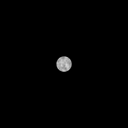
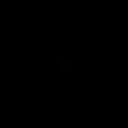
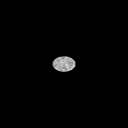
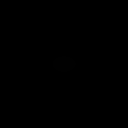
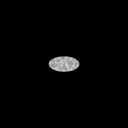
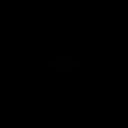
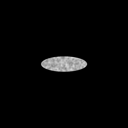
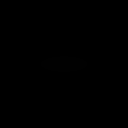
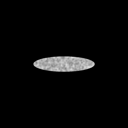
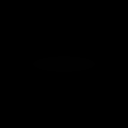

In [4]:
# Load 5 representative rows (one per aspect ratio) at angle=0, with images
representative_cell_ids = (
    at_zero[at_zero["stain_type"] == "spatial"]
    .drop_duplicates("aspect_ratio")
    .sort_values("aspect_ratio")["cell_id"]
    .tolist()[:5]
)

sample_table = pq.read_table(
    DATASET,
    filters=[
        ("cell_id", "in", representative_cell_ids),
        ("angle_deg", "=", 0.0),
    ],
)
sample_df = sample_table.to_pandas()

# Build a tidy subset: metadata + image/mask + a few key features
preview_cols = (
    META_COLS
    + IMAGE_COLS
    + [
        "Area",
        "Eccentricity",
        "MajorAxisLength",
        "Intensity_MeanIntensity",
        "Orientation",
    ]
)
sample_df = sample_df[preview_cols].sort_values("aspect_ratio").reset_index(drop=True)

# CytoDataFrame auto-detects image/mask columns and renders them inline
CytoDataFrame(sample_df)

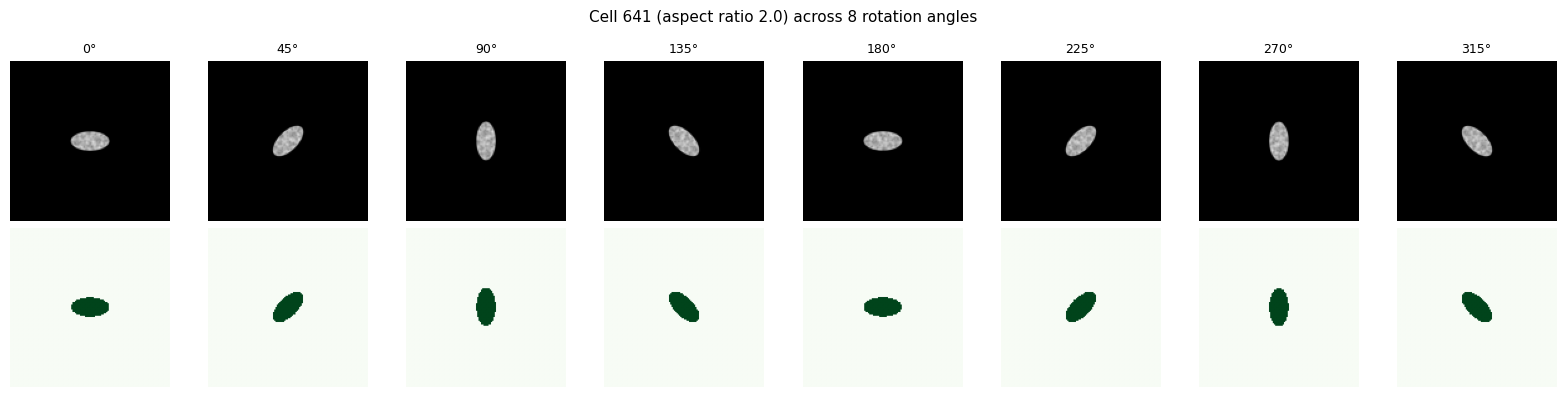

In [5]:
# Show same cell at multiple rotation angles using matplotlib
from ome_arrow import OMEArrow

example_id = representative_cell_ids[2]  # aspect_ratio=2.0
angles_to_show = [0, 45, 90, 135, 180, 225, 270, 315]

rows = (
    pq.read_table(
        DATASET,
        filters=[
            ("cell_id", "=", example_id),
            ("angle_deg", "in", [float(a) for a in angles_to_show]),
        ],
        columns=["angle_deg", "image", "mask"],
    )
    .to_pandas()
    .sort_values("angle_deg")
)

fig, axes = plt.subplots(2, len(angles_to_show), figsize=(16, 4))
for col, (_, row) in enumerate(rows.iterrows()):
    img_arr = OMEArrow(row["image"]).export(how="numpy").squeeze()
    msk_arr = OMEArrow(row["mask"]).export(how="numpy").squeeze()
    axes[0, col].imshow(img_arr, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(f"{int(row['angle_deg'])}°", fontsize=9)
    axes[0, col].axis("off")
    axes[1, col].imshow(msk_arr, cmap="Greens", vmin=0, vmax=1)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Image", fontsize=9)
axes[1, 0].set_ylabel("Mask", fontsize=9)
plt.suptitle(
    f"Cell {example_id} (aspect ratio 2.0) across 8 rotation angles", fontsize=11
)
plt.tight_layout()
plt.show()

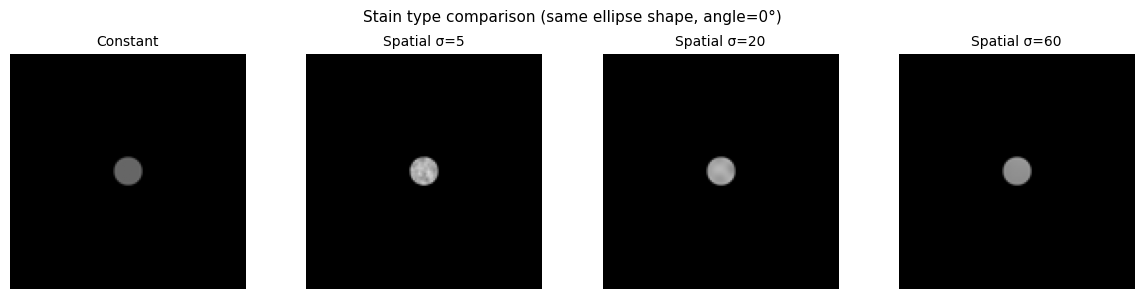

In [6]:
# Stain type comparison panel
spatial_examples = (
    at_zero[at_zero["stain_type"] == "spatial"]
    .drop_duplicates("stain_corr")
    .sort_values("stain_corr")[["cell_id", "stain_corr"]]
)
stain_rows = pq.read_table(
    DATASET,
    filters=[
        (
            "cell_id",
            "in",
            spatial_examples["cell_id"].tolist()
            + at_zero[at_zero["stain_type"] == "constant"]["cell_id"].head(1).tolist(),
        ),
        ("angle_deg", "=", 0.0),
    ],
    columns=["cell_id", "stain_type", "stain_corr", "image"],
).to_pandas()
stain_rows = stain_rows.drop_duplicates(
    subset=["stain_type", "stain_corr"]
).sort_values(["stain_type", "stain_corr"])
labels = [
    f"{'Constant' if r.stain_type == 'constant' else f'Spatial σ={int(r.stain_corr)}'}"
    for _, r in stain_rows.iterrows()
]

fig, axes = plt.subplots(1, len(stain_rows), figsize=(12, 3))
for ax, (_, row), label in zip(axes, stain_rows.iterrows(), labels):
    img_arr = OMEArrow(row["image"]).export(how="numpy").squeeze()
    ax.imshow(img_arr, cmap="gray", vmin=0, vmax=255)
    ax.set_title(label, fontsize=10)
    ax.axis("off")
plt.suptitle("Stain type comparison (same ellipse shape, angle=0°)", fontsize=11)
plt.tight_layout()
plt.show()

## 3 — Sensitivity metrics

We compute two complementary metrics per feature.

### Metric 1 — Coefficient of Variation (CV)

For each cell, CV = std(feature across 72 angles) / |mean(feature across 72 angles)|.
We then average CV over all 1,600 cells.

**Limitation:** CV is undefined (or explodes) when the feature mean is near zero.
This affects moment features (`CentralMoment_*`, `NormalizedMoment_*`, `HuMoment_*`,
`InertiaTensor_*`) and `Orientation` (which oscillates symmetrically around 0).
Those features report astronomically large CVs that are mathematical artifacts,
not genuine sensitivity.

### Metric 2 — Rotation Sensitivity Index (RSI)

$$\text{RSI} = \frac{\text{mean within-cell variance across angles}}{\text{between-cell variance at angle = 0}}$$

- **Numerator** — how much does this feature vary as we rotate a single cell?
- **Denominator** — how much does this feature vary across different cells (biology)?
- **RSI > 1**: rotation adds more variance than biology → feature is dominated by orientation artefact
- **RSI < 0.01**: rotation contributes < 1% of the biological spread → essentially invariant
- **No division by mean** — valid for features that oscillate around zero

In [7]:
# Load all feature data (no images)
df = pq.read_table(DATASET, columns=META_COLS + feature_cols).to_pandas()
print(f"Rows: {len(df):,}  |  Feature columns: {len(feature_cols)}")

Rows: 115,200  |  Feature columns: 372


In [8]:
# --- Metric 1: CV ---
grp = df.groupby("cell_id")[feature_cols]
cell_cv = grp.std() / grp.mean().abs().replace(0, np.nan)
mean_cv = cell_cv.mean()

print("CV — top 10 most sensitive (may include zero-mean artifacts):")
print(mean_cv.sort_values(ascending=False).head(10).to_string())

CV — top 10 most sensitive (may include zero-mean artifacts):
HuMoment_6              1.350777e+12
NormalizedMoment_1_1    3.729794e+08
InertiaTensor_0_1       3.580491e+08
InertiaTensor_1_0       3.580491e+08
NormalizedMoment_3_3    2.468884e+08
CentralMoment_1_1       2.227664e+08
NormalizedMoment_3_0    1.786818e+08
NormalizedMoment_0_3    1.564049e+08
CentralMoment_1_2       1.415099e+08
NormalizedMoment_1_3    1.341705e+08


In [9]:
# --- Metric 2: Rotation Sensitivity Index (RSI) ---
# Within-cell variance: for each cell, variance of feature across 72 angles
within_var = grp.var().mean()  # mean over cells → Series indexed by feature

# Between-cell variance: variance of feature across all 1,600 cells at angle=0
at_zero_feats = df[df["angle_deg"] == 0.0][feature_cols]
between_var = at_zero_feats.var()

rsi = within_var / between_var.replace(0, np.nan)

print("RSI — top 10 most sensitive (rotation variance / between-cell variance):")
print(rsi.sort_values(ascending=False).head(10).to_string())
print()
print("RSI — top 10 most stable:")
print(rsi.sort_values(ascending=True).head(10).to_string())

RSI — top 10 most sensitive (rotation variance / between-cell variance):
CentralMoment_1_1       1.036114e+06
InertiaTensor_0_1       4.277750e+05
InertiaTensor_1_0       4.277750e+05
CentralMoment_1_3       4.216638e+05
NormalizedMoment_3_3    3.468833e+05
NormalizedMoment_3_1    1.528853e+05
NormalizedMoment_1_3    4.337257e+04
NormalizedMoment_1_1    3.035392e+04
HuMoment_4              7.943800e+02
NormalizedMoment_2_2    2.542386e+02

RSI — top 10 most stable:
Intensity_IntegratedIntensity    0.000005
EquivalentDiameter               0.000009
FilledArea                       0.000009
Area                             0.000009
CentralMoment_0_0                0.000009
SpatialMoment_0_0                0.000009
MajorAxisLength                  0.000015
ConvexArea                       0.000020
InertiaTensorEigenvalues_0       0.000023
InertiaTensorEigenvalues_1       0.000023


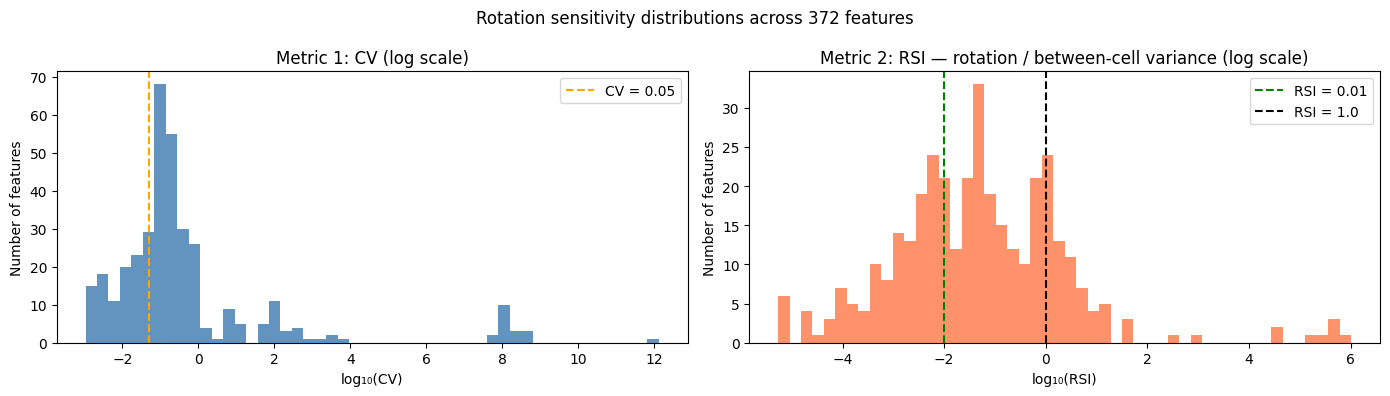

  RSI < 0.01 (very stable):  130 / 359 features (36%)
  RSI < 0.10:  223 / 359 features (62%)
  RSI < 1.00:  291 / 359 features (81%)


In [10]:
# Side-by-side distribution of both metrics (log scale, excluding NaN / constant features)  # noqa: E501
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cv_plot = np.log10(mean_cv.replace(0, np.nan).dropna().clip(lower=1e-6))
rsi_plot = np.log10(rsi.replace(0, np.nan).dropna().clip(lower=1e-6))

axes[0].hist(cv_plot, bins=50, color="steelblue", edgecolor="none", alpha=0.85)
axes[0].axvline(np.log10(0.05), color="orange", linestyle="--", label="CV = 0.05")
axes[0].set_xlabel("log₁₀(CV)")
axes[0].set_ylabel("Number of features")
axes[0].set_title("Metric 1: CV (log scale)")
axes[0].legend()

axes[1].hist(rsi_plot, bins=50, color="coral", edgecolor="none", alpha=0.85)
axes[1].axvline(np.log10(0.01), color="green", linestyle="--", label="RSI = 0.01")
axes[1].axvline(0, color="black", linestyle="--", label="RSI = 1.0")
axes[1].set_xlabel("log₁₀(RSI)")
axes[1].set_ylabel("Number of features")
axes[1].set_title("Metric 2: RSI — rotation / between-cell variance (log scale)")
axes[1].legend()

plt.suptitle("Rotation sensitivity distributions across 372 features", fontsize=12)
plt.tight_layout()
plt.show()

for thresh, label in [
    (0.01, "RSI < 0.01 (very stable)"),
    (0.1, "RSI < 0.10"),
    (1.0, "RSI < 1.00"),
]:
    n = (rsi < thresh).sum()
    print(
        f"  {label}: {n:>4} / {rsi.notna().sum()} features"  # noqa: E501
        f" ({100 * n / rsi.notna().sum():.0f}%)"
    )

## 4 — Per-feature report

A single table with both metrics, feature category, and absolute variance
statistics — one row per feature.

In [11]:
def categorise(name: str) -> str:
    """Assign a cp_measure feature to a broad measurement category."""
    if any(
        x in name
        for x in [
            "SpatialMoment",
            "CentralMoment",
            "NormalizedMoment",
            "HuMoment",
            "InertiaTensor",
        ]
    ):
        return "Moments"
    if name.startswith("Zernike_"):
        return "Zernike"
    if name.startswith("RadialDistribution_ZernikeMagnitude"):
        return "RadialZernikeMag"
    if name.startswith("RadialDistribution_ZernikePhase"):
        return "RadialZernikePhase"
    if name.startswith("RadialDistribution_"):
        return "RadialDistribution"
    if name.startswith("Granularity_"):
        return "Granularity"
    if name.startswith("Intensity_") or name.startswith("Location_"):
        return "Intensity"
    if any(
        h in name
        for h in [
            "AngularSecondMoment",
            "Contrast",
            "Correlation",
            "Variance",
            "InverseDifferenceMoment",
            "SumAverage",
            "SumVariance",
            "SumEntropy",
            "Entropy",
            "DifferenceVariance",
            "DifferenceEntropy",
            "InfoMeas",
        ]
    ):
        return "Texture"
    if "Feret" in name:
        return "Feret"
    return "Shape"


within_std = grp.std().mean()  # mean within-cell std across rotation
between_std = at_zero_feats.std()  # between-cell std at angle=0

report = pd.DataFrame(
    {
        "feature": feature_cols,
        "category": [categorise(f) for f in feature_cols],
        "cv": mean_cv.values,
        "rsi": rsi.values,
        "within_std": within_std.values,
        "between_std": between_std.values,
        "is_constant": (between_std.values == 0),
    }
)

# Ranks (lower rank = more sensitive)
report["rank_cv"] = report["cv"].rank(ascending=False, na_option="bottom").astype(int)
report["rank_rsi"] = report["rsi"].rank(ascending=False, na_option="bottom").astype(int)

report = report.sort_values("rsi", ascending=False).reset_index(drop=True)

print(f"Feature report: {len(report)} features")
print(f"Constant features (zero between-cell variance): {report['is_constant'].sum()}")
print("\nCategory summary (median RSI):")
print(
    report.groupby("category")[["rsi", "cv"]]
    .median()
    .sort_values("rsi", ascending=False)
    .round(4)
    .to_string()
)

Feature report: 372 features
Constant features (zero between-cell variance): 13

Category summary (median RSI):
                       rsi        cv
category                            
Moments             2.8748    0.7950
RadialZernikePhase  1.0860  109.2930
Zernike             0.2699    0.5211
Granularity         0.2507    0.9257
RadialZernikeMag    0.1566    0.3886
RadialDistribution  0.0393    0.0162
Texture             0.0109    0.0798
Intensity           0.0084    0.0186
Shape               0.0030    0.0064
Feret               0.0002    0.0055


In [12]:
# Full sortable report — most sensitive at top by default
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", "{:.4g}".format)
report[
    [
        "feature",
        "category",
        "rsi",
        "cv",
        "within_std",
        "between_std",
        "rank_rsi",
        "rank_cv",
    ]
]

,feature,category,rsi,cv,within_std,between_std,rank_rsi,rank_cv
0,CentralMoment_1_1,Moments,1.036e+06,2.228e+08,4.502e+05,828.7,1,6
1,InertiaTensor_0_1,Moments,4.278e+05,3.58e+08,116.4,0.2691,2,3
2,InertiaTensor_1_0,Moments,4.278e+05,3.58e+08,116.4,0.2691,2,3
3,CentralMoment_1_3,Moments,4.217e+05,4815,5.339e+08,1.751e+06,4,20
4,NormalizedMoment_3_3,Moments,3.469e+05,2.469e+08,0.002857,7.548e-06,5,5
...,...,...,...,...,...,...,...,...
367,Granularity_13,Granularity,NaN,NaN,0,0,366,368
368,Granularity_14,Granularity,NaN,NaN,0,0,366,368
369,Granularity_15,Granularity,NaN,NaN,0,0,366,368
370,Granularity_16,Granularity,NaN,NaN,0,0,366,368


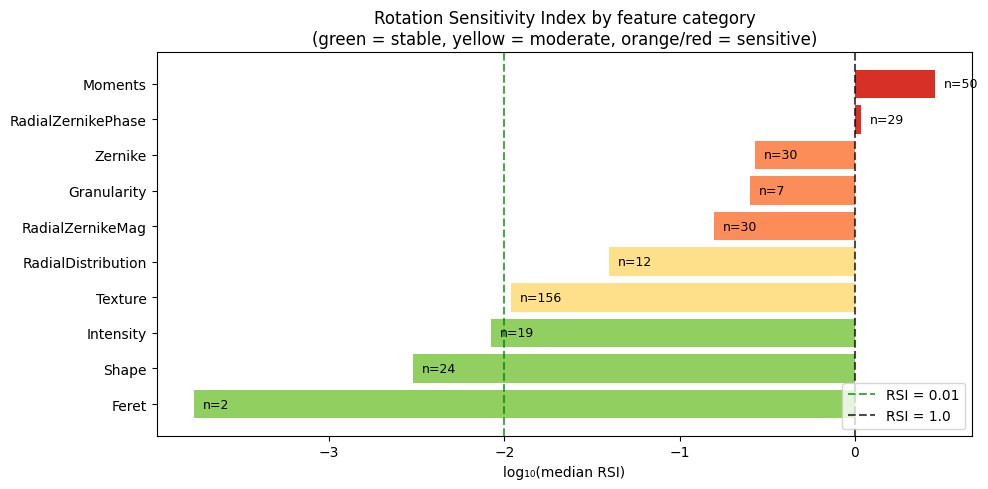

In [13]:
# RSI heatmap by category — median RSI per category as a bar chart
cat_summary = (
    report[~report["is_constant"]]
    .groupby("category")["rsi"]
    .agg(["median", "count"])
    .sort_values("median", ascending=True)
)

colors = [
    "#d73027"
    if m > 1.0
    else "#fc8d59"
    if m > 0.1
    else "#fee08b"
    if m > 0.01
    else "#91cf60"
    for m in cat_summary["median"]
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    cat_summary.index,
    np.log10(cat_summary["median"].clip(lower=1e-6)),
    color=colors,
    edgecolor="none",
)
ax.axvline(np.log10(0.01), color="green", linestyle="--", alpha=0.7, label="RSI = 0.01")
ax.axvline(0, color="black", linestyle="--", alpha=0.7, label="RSI = 1.0")

for bar, (cat, row) in zip(bars, cat_summary.iterrows()):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"n={int(row['count'])}",
        va="center",
        fontsize=9,
    )

ax.set_xlabel("log₁₀(median RSI)")
ax.set_title(
    "Rotation Sensitivity Index by feature category\n"
    "(green = stable, yellow = moderate, orange/red = sensitive)"
)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5 — Rotation profiles for representative features

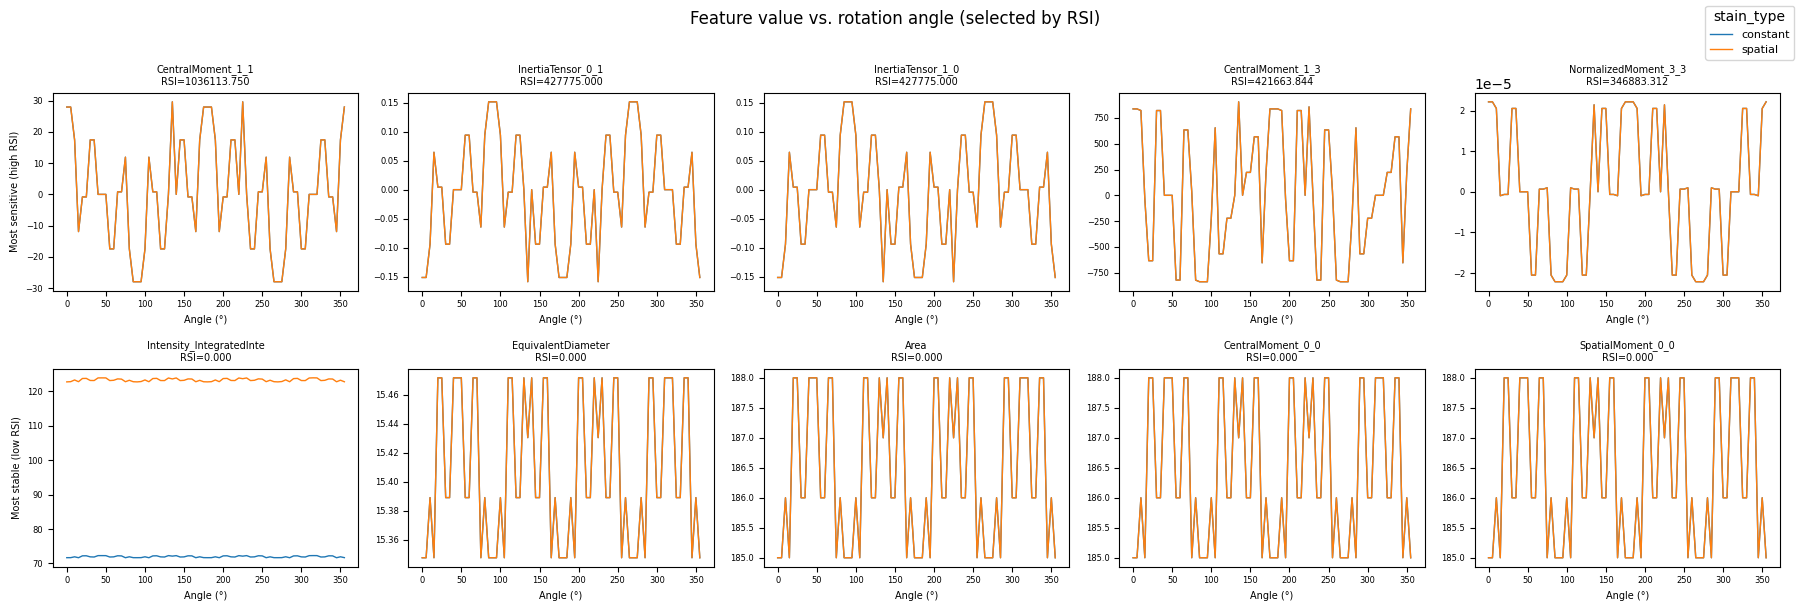

In [14]:
# Use RSI to pick top-5 most sensitive and top-5 most stable (excluding constants)
non_constant = report[~report["is_constant"]]
top_sensitive = non_constant.nlargest(5, "rsi")["feature"].tolist()
top_stable = non_constant.nsmallest(5, "rsi")["feature"].tolist()

example_cells = (
    df.groupby("stain_type", observed=True)
    .apply(lambda g: g["cell_id"].iloc[0])
    .to_dict()
)

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for row_i, (features, title) in enumerate(
    [
        (top_sensitive, "Most sensitive (high RSI)"),
        (top_stable, "Most stable (low RSI)"),
    ]
):
    for col_i, feat in enumerate(features):
        ax = axes[row_i, col_i]
        for stain_type, cell_id in example_cells.items():
            sub = df[df["cell_id"] == cell_id].sort_values("angle_deg")
            ax.plot(sub["angle_deg"], sub[feat], label=stain_type, linewidth=1)
        rsi_val = non_constant.set_index("feature").loc[feat, "rsi"]
        ax.set_title(f"{feat[:24]}\nRSI={rsi_val:.3f}", fontsize=7)
        ax.set_xlabel("Angle (°)", fontsize=7)
        if col_i == 0:
            ax.set_ylabel(title, fontsize=7)
        ax.tick_params(labelsize=6)

handles, labels_ = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="upper right", fontsize=8, title="stain_type")
plt.suptitle("Feature value vs. rotation angle (selected by RSI)", y=1.01)
plt.tight_layout()
plt.show()

## 6 — Sensitivity by cell parameter

Feature: Granularity_6  (RSI=48.6471)


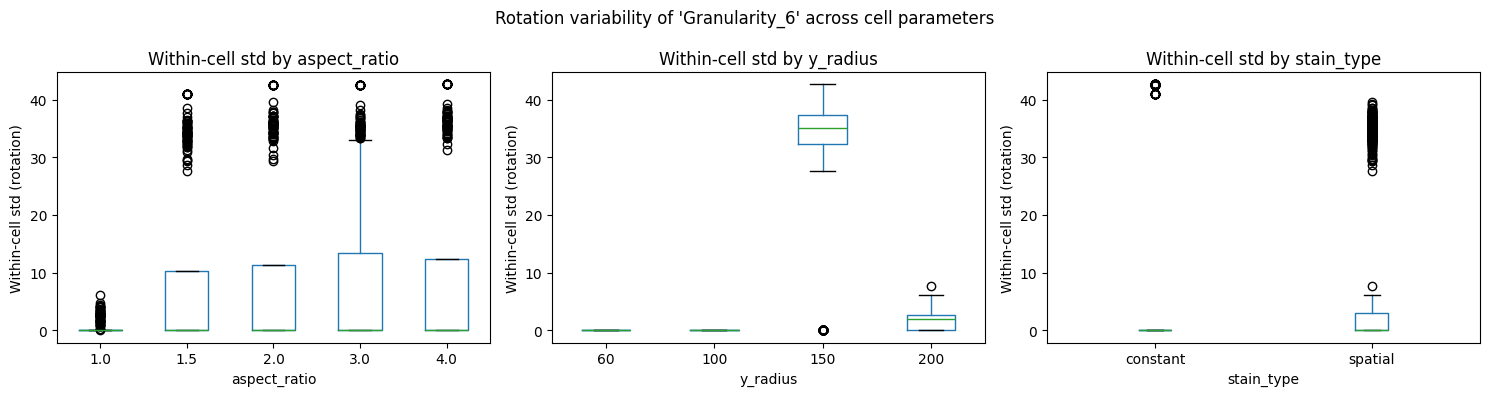

In [15]:
# Does rotation sensitivity depend on aspect ratio, stain type, or cell size?
# Use the most sensitive non-constant, non-moment feature by RSI
top_feat = (
    non_constant[~non_constant["category"].isin(["Moments"])]
    .nlargest(1, "rsi")["feature"]
    .iloc[0]
)
print(f"Feature: {top_feat}  (RSI={rsi[top_feat]:.4f})")

per_cell = (
    df.groupby(["cell_id", "aspect_ratio", "stain_type", "stain_corr", "y_radius"])[
        top_feat
    ]
    .agg(within_std="std")
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["aspect_ratio", "y_radius", "stain_type"]):
    per_cell.boxplot(column="within_std", by=col, ax=ax, grid=False)
    ax.set_title(f"Within-cell std by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Within-cell std (rotation)")
plt.suptitle(f"Rotation variability of '{top_feat}' across cell parameters")
plt.tight_layout()
plt.show()